# SQL-IDS: Tek Notebook Akisi (Detayli Aciklamali)

Bu notebook SQL Injection (SQLi) tespiti icin tek dosyada adim adim makine ogrenmesi akisi sunar.

Veri `merge_clean_preprocess.ipynb` ciktisindan yuklenir. Overfitting riskini azaltmak icin
train / validation / test ayrimi, regularize modeller ve train-validation gap analizi uygulanir.

## 1) Hazirlik ve Veri Yukleme

Bu bolumde kutuphaneler import edilir ve `merge_clean_preprocess.ipynb` ciktisi olan hazir dataset yuklenir.

In [1]:
# Standart kutuphaneler
import os  # Dosya/klasor islemleri icin
import pickle  # Model ve vectorizer kaydetme/yukleme icin

# Veri ve gorsellestirme kutuphaneleri
import pandas as pd  # Tablo islemleri
import seaborn as sns  # Islenmis grafikler
import matplotlib.pyplot as plt  # Temel grafik cizimi

# Makine ogrenmesi kutuphaneleri
from sklearn.feature_extraction.text import TfidfVectorizer  # Metni sayisallastirma
from sklearn.model_selection import train_test_split  # Train/test ayirma
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)  # Degerlendirme metrikleri
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # RF + Ensemble modeli
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier  # XGBoost siniflandirici

# Grafik temasini ve varsayilan boyutu belirle
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Veri yukleme

`data/merged_cleaned_preprocessed.csv` dosyasi okunur. Bu dosyada `Sentence` ve `Label` (0/1) kolonlari
`merge_clean_preprocess.ipynb` icinde zaten hazirlanmistir.

In [2]:
# Hazir dataset (merge_clean_preprocess.ipynb ciktisi)
DATASET_PATH = "./data/merged_cleaned_preprocessed.csv"

df = pd.read_csv(DATASET_PATH, low_memory=False)

required_cols = {"Sentence", "Label"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Dataset eksik kolonlar: {missing}")

print("Veri boyutu:", df.shape)
print("Label dagilimi:")
print(df["Label"].value_counts())

df.head()

Veri boyutu: (1665053, 3)
Label dagilimi:
Label
0    1490101
1     174952
Name: count, dtype: int64


,Sentence,normalized_query,Label
0,"SELECT n.type, c.name as country_name, COUNT(n...","select n.type, c.name as country_name, count(n...",0
1,"SELECT a.id, a.ident, a.name, a.latitude_deg, ...","select a.id, a.ident, a.name, a.latitude_deg, ...",0
2,UPDATE airport_frequencies SET type = 'TWR' WH...,update airport_frequencies set type = 'twr' wh...,0
3,"SELECT name, 'airport' AS type FROM airport WH...","select name, 'airport' as type from airport wh...",0
4,"SELECT name, 'airport' AS entity_type FROM air...","select name, 'airport' as entity_type from air...",0


## 2) Vektorlestirme ve Modelleme Hazirligi

Veri uc parcaya ayrilir (data leakage onlenir):
- **Train** (%68): model egitimi
- **Validation** (%12): overfitting izleme (train–val metrik karsilastirmasi)
- **Test** (%20): nihai performans (holdout)

TF-IDF yalnizca train uzerinde fit edilir; val ve test transform edilir.

### Once bol, sonra vektorize et (data leakage onleme)

1. **Ham metin:** `train_test_split` ile `X_train`, `X_val`, `X_test` (metin; henuz TF-IDF yok)
2. **Train:** `fit_transform(X_train)` — vektorizer yalnizca egitim kelime dagarcigini ogrenir
3. **Val / Test:** `transform(...)` — `fit` yapilmaz; holdout metin vektorizer tarafindan gorulmez

In [3]:
# --- 1) Ham metin: once bol (TF-IDF oncesi; tum X uzerinde fit YOK) ---
X = df["Sentence"]
y = df["Label"]

TEST_SIZE = 0.20
VAL_SIZE = 0.15

# Holdout test
X_remain, X_test, y_remain, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=y,
)

# Validation (kalan havuzun %15'i)
X_train, X_val, y_train, y_val = train_test_split(
    X_remain,
    y_remain,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=y_remain,
)

# --- 2) TF-IDF: yalnizca train'de fit + transform; val/test sadece transform ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000, analyzer="char_wb", ngram_range=(3, 5))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Sonraki hucrelerde kullanilan matris takma adlari (sparse TF-IDF)
X_train, X_val, X_test = X_train_tfidf, X_val_tfidf, X_test_tfidf

print("Train shape     :", X_train_tfidf.shape, "| Label:", dict(y_train.value_counts()))
print("Validation shape:", X_val_tfidf.shape, "| Label:", dict(y_val.value_counts()))
print("Test shape      :", X_test_tfidf.shape, "| Label:", dict(y_test.value_counts()))
print("Vocabulary size (train-only fit):", len(tfidf_vectorizer.vocabulary_))

Train shape     : (1132235, 5000) | Label: {0: np.int64(1013267), 1: np.int64(118968)}
Validation shape: (199807, 5000) | Label: {0: np.int64(178813), 1: np.int64(20994)}
Test shape      : (333011, 5000) | Label: {0: np.int64(298021), 1: np.int64(34990)}
Vocabulary size (train-only fit): 5000


## 3) Bireysel Model Egitimi ve Kayit

Regularize edilmis modeller yalnizca **train** setinde egitilir:
- XGBoost (L1/L2, subsample; sabit agac sayisi — ensemble uyumlulugu icin early stopping yok)
- Random Forest (sinirli derinlik, min_samples_leaf)
- SGD / Logistic Regression (L2, class_weight='balanced')

Ardindan modeller ve vectorizer `models/` klasorune kaydedilir.

In [4]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier

# Sinif dengesizligi
oran = (y_train == 0).sum() / (y_train == 1).sum()
print(f"XGBoost scale_pos_weight (sinif 0/1 orani): {oran:.4f}")

# XGBoost: regularizasyon (early_stopping VotingClassifier ile uyumsuz; n_estimators sabit)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=oran,
)
xgb_model.fit(X_train, y_train)

# Random Forest: daha sig agaclar
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)
rf_model.fit(X_train, y_train)

# SGD: L2 regularizasyon
sgd_model = SGDClassifier(
    loss="log_loss",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-3,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)
sgd_model.fit(X_train, y_train)

# Logistic Regression: daha guclu regularizasyon (dusuk C)
lr_model = LogisticRegression(
    C=0.1,
    max_iter=2000,
    random_state=42,
    class_weight="balanced",
)
lr_model.fit(X_train, y_train)

models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "SGD (Linear SVM)": sgd_model,
    "Logistic Regression": lr_model,
}

print("Tum modeller train seti uzerinde egitildi.")

XGBoost scale_pos_weight (sinif 0/1 orani): 8.5171
Tum modeller train seti uzerinde egitildi.


### Train vs Validation: Overfitting Analizi

Her model icin train ve validation metrikleri karsilastirilir.
- **Gap** (Train - Validation): buyuk pozitif fark overfitting belirtisidir.
- Cikti: `plots/train_val_metrics.csv`, `plots/train_val_gap.png`


Train vs Validation metrikleri:

                        Train                               Validation                               Gap (Train-Val)                              
Metric               Accuracy  F1-Score Precision    Recall   Accuracy  F1-Score Precision    Recall        Accuracy  F1-Score Precision    Recall
Model                                                                                                                                             
Logistic Regression  0.993162  0.967271  0.972980  0.961628   0.993258  0.967719  0.973810  0.961703   -9.629755e-05 -0.000448 -0.000830 -0.000075
Random Forest        0.987935  0.943587  0.927477  0.960267   0.987758  0.942816  0.925803  0.960465    1.771801e-04  0.000771  0.001673 -0.000198
SGD (Linear SVM)     0.991539  0.959362  0.968383  0.950508   0.991652  0.959888  0.969305  0.950653   -1.130851e-04 -0.000526 -0.000923 -0.000145
XGBoost              0.992494  0.964322  0.963194  0.965453   0.992493  0.964298  0.9

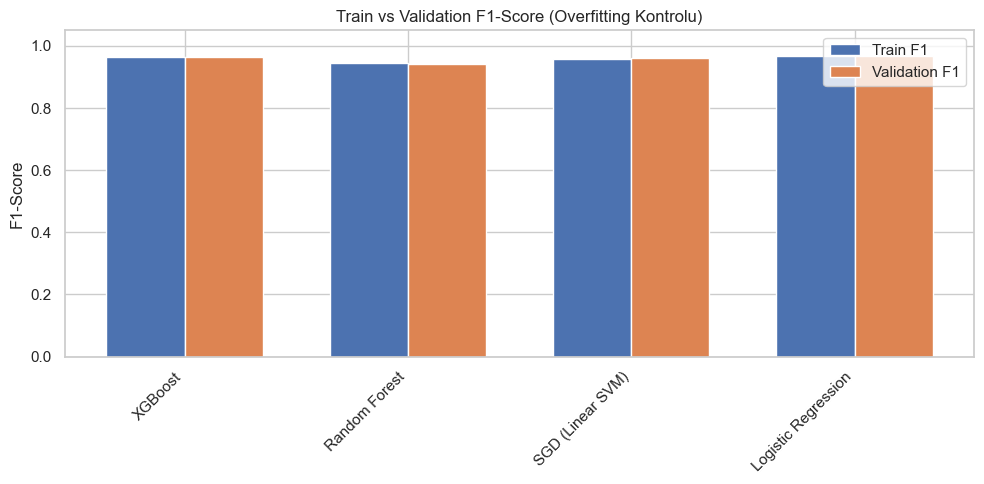

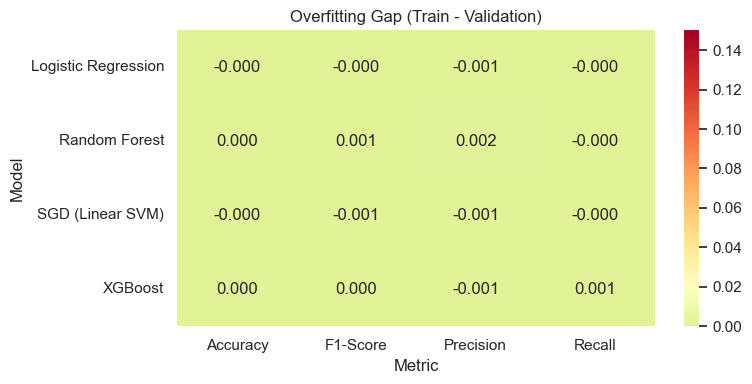


Kaydedildi: ./plots/train_val_metrics.csv, ./plots/train_val_gap.png


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("plots", exist_ok=True)

METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1-Score"]


def evaluate_split(model, X, y_true):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="binary", zero_division=0),
    }


train_val_rows = []
for model_name, model in models.items():
    train_m = evaluate_split(model, X_train, y_train)
    val_m = evaluate_split(model, X_val, y_val)
    for metric in METRIC_COLS:
        gap = train_m[metric] - val_m[metric]
        train_val_rows.append(
            {
                "Model": model_name,
                "Metric": metric,
                "Train": train_m[metric],
                "Validation": val_m[metric],
                "Gap (Train-Val)": gap,
            }
        )

train_val_df = pd.DataFrame(train_val_rows)
train_val_df.to_csv("./plots/train_val_metrics.csv", index=False, float_format="%.6f")

print("Train vs Validation metrikleri:\n")
pivot = train_val_df.pivot(index="Model", columns="Metric", values=["Train", "Validation", "Gap (Train-Val)"])
print(pivot.to_string())

# Ortalama gap ozeti
gap_summary = (
    train_val_df.groupby("Model")["Gap (Train-Val)"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="Mean_Gap")
)
print("\nOrtalama metrik farki (Train - Validation), yuksek = daha fazla overfitting riski:\n")
print(gap_summary.to_string(index=False))

# Gorsel: F1 gap
f1_gap = train_val_df[train_val_df["Metric"] == "F1-Score"].copy()
plt.figure(figsize=(10, 5))
x = range(len(f1_gap))
width = 0.35
plt.bar([i - width / 2 for i in x], f1_gap["Train"], width, label="Train F1")
plt.bar([i + width / 2 for i in x], f1_gap["Validation"], width, label="Validation F1")
plt.xticks(x, f1_gap["Model"], rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("F1-Score")
plt.title("Train vs Validation F1-Score (Overfitting Kontrolu)")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/train_val_gap.png", dpi=150)
plt.show()
plt.close()

# Tum metrikler icin gap heatmap
gap_pivot = train_val_df.pivot(index="Model", columns="Metric", values="Gap (Train-Val)")
plt.figure(figsize=(8, 4))
sns.heatmap(gap_pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", center=0.02, vmin=0, vmax=0.15)
plt.title("Overfitting Gap (Train - Validation)")
plt.tight_layout()
plt.savefig("./plots/train_val_gap_heatmap.png", dpi=150)
plt.show()
plt.close()

print("\nKaydedildi: ./plots/train_val_metrics.csv, ./plots/train_val_gap.png")

### Modellerin ve TF-IDF nesnesinin kaydedilmesi

Bu adim yeniden egitim yapmadan modeli tekrar kullanabilmek icin gereklidir.
Model ve vectorizer artefaktlari `models/` klasorune yazilir.

In [6]:
import os
import pickle

# Model artefaktlarini yazmak icin klasor olustur (yoksa)
os.makedirs("models", exist_ok=True)

# XGBoost modelini kaydet
with open("./models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Random Forest modelini kaydet
with open("./models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# SGD modelini kaydet
with open("./models/sgd_model.pkl", "wb") as f:
    pickle.dump(sgd_model, f)

# Logistic Regression modelini kaydet
with open("./models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# TF-IDF vectorizer nesnesini kaydet
with open("./models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Tum modeller ve vectorizer basariyla kaydedildi.")

Tum modeller ve vectorizer basariyla kaydedildi.


## 4) Performans Degerlendirmesi (Holdout Test)

Bu bolumde modeller **daha once hic kullanilmayan test** seti uzerinde degerlendirilir.
Train/validation analizi (Bolum 3.1) overfitting icin yapildi; burada genelleme performansi olculur.
- Accuracy, Precision, Recall, F1-Score
- Confusion matrix (`plots/`)
- `plots/model_metrics.csv`

In [7]:
import pickle

# Daha once kaydedilen model dosyalarini tekrar yukle
# Bu adim yeniden egitim yapmadan degerlendirme icin kullanilir.
with open("./models/xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("./models/random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("./models/sgd_model.pkl", "rb") as f:
    sgd_model = pickle.load(f)

with open("./models/logistic_regression_model.pkl", "rb") as f:
    lr_model = pickle.load(f)
 
# TF-IDF vectorizer nesnesini yukle
with open("./models/tfidf_vectorizer.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)

print("Tum modeller ve vectorizer basariyla yuklendi.")

# Gerekirse manuel test icin ornek kod:
# raw_texts = ["ornek metin 1", "ornek metin 2"]
# X_new_tfidf = tfidf_vectorizer.transform(raw_texts)  # yeni veri: sadece transform
# y_pred = ensemble_model.predict(X_new_tfidf)
# print(y_pred)

Tum modeller ve vectorizer basariyla yuklendi.



===== XGBoost =====
Accuracy : 0.9924
Precision: 0.9626
Recall   : 0.9652
F1-Score : 0.9639
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    298021
           1       0.96      0.97      0.96     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.98      0.98    333011
weighted avg       0.99      0.99      0.99    333011



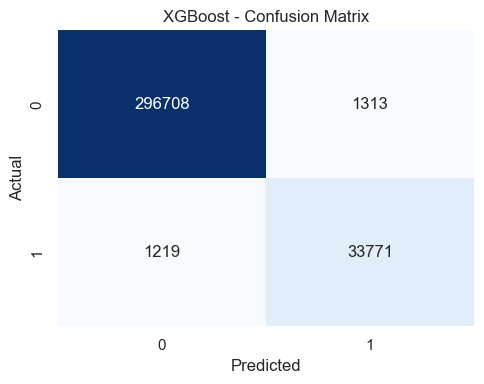


===== Random Forest =====
Accuracy : 0.9876
Precision: 0.9257
Recall   : 0.9590
F1-Score : 0.9421
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    298021
           1       0.93      0.96      0.94     34990

    accuracy                           0.99    333011
   macro avg       0.96      0.97      0.97    333011
weighted avg       0.99      0.99      0.99    333011



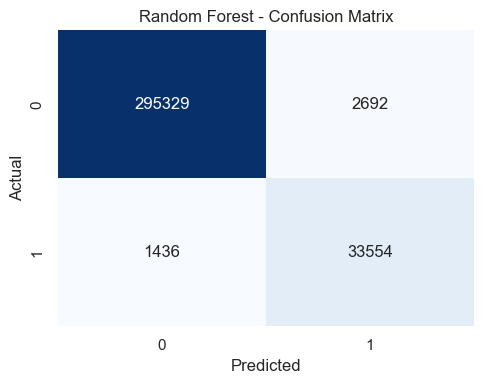


===== SGD (Linear SVM) =====
Accuracy : 0.9916
Precision: 0.9685
Recall   : 0.9511
F1-Score : 0.9597
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    298021
           1       0.97      0.95      0.96     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.97      0.98    333011
weighted avg       0.99      0.99      0.99    333011



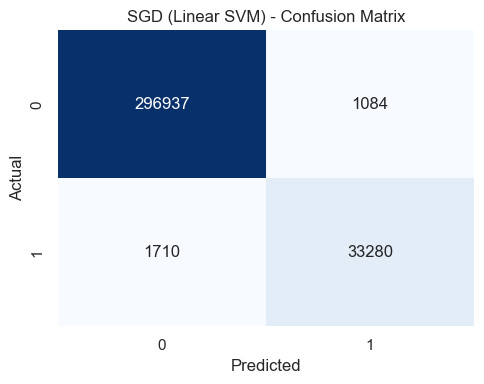


===== Logistic Regression =====
Accuracy : 0.9932
Precision: 0.9729
Recall   : 0.9619
F1-Score : 0.9674
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    298021
           1       0.97      0.96      0.97     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.98      0.98    333011
weighted avg       0.99      0.99      0.99    333011



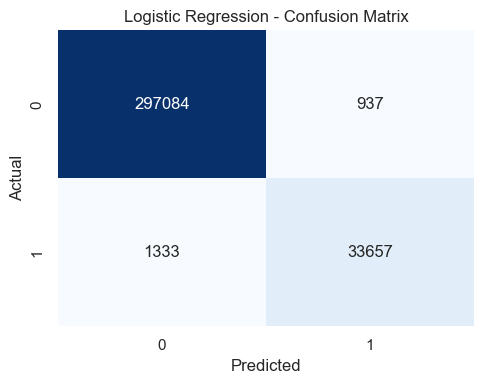


Tum modellerin karsilastirmali metrikleri:

              Model Accuracy Precision Recall F1-Score
            XGBoost   0.9924    0.9626 0.9652   0.9639
      Random Forest   0.9876    0.9257 0.9590   0.9421
   SGD (Linear SVM)   0.9916    0.9685 0.9511   0.9597
Logistic Regression   0.9932    0.9729 0.9619   0.9674

Metrikler kaydedildi: ./plots/model_metrics.csv


In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Plot dosyalari icin klasor
os.makedirs("plots", exist_ok=True)

metrics_rows = []

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")

    # Tahmin
    y_pred = model.predict(X_test)

    # Metrikler (SQLi = pozitif sinif, binary average)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
    rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)
    metrics_rows.append(
        {
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
        }
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # Classification Report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    # Dosyaya kaydet (or: xgboost_confusion_matrix.png)
    file_key = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"./plots/{file_key}_confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

# Tum modellerin ozet metrik tablosu
import pandas as pd

metrics_df = pd.DataFrame(metrics_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
print("\nTum modellerin karsilastirmali metrikleri:\n")
print(metrics_df.to_string(index=False, formatters={c: "{:.4f}".format for c in metric_cols}))
metrics_df.to_csv("./plots/model_metrics.csv", index=False, float_format="%.6f")
print("\nMetrikler kaydedildi: ./plots/model_metrics.csv")

## 5) Ensemble (Topluluk) Mimarisi

Bu bolumde temel modeller tek bir topluluk modelinde birlestirilir.
`VotingClassifier` (soft voting) ile model olasiliklari bir araya getirilir.
Ensemble sonucu da confusion matrix olarak kaydedilir ve model `.pkl` olarak disariya yazilir.


===== Ensemble =====
Accuracy : 0.9932
Precision: 0.9707
Recall   : 0.9641
F1-Score : 0.9674
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    298021
           1       0.97      0.96      0.97     34990

    accuracy                           0.99    333011
   macro avg       0.98      0.98      0.98    333011
weighted avg       0.99      0.99      0.99    333011



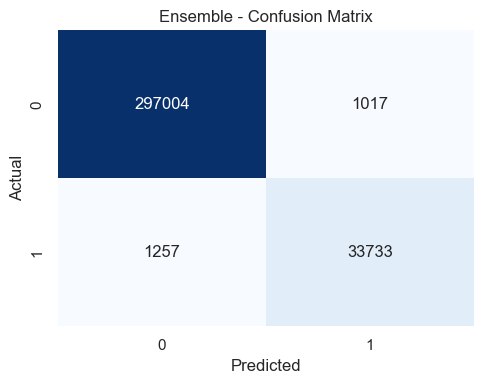

ensemble_model.pkl basariyla kaydedildi.
./plots/ensemble_confusion_matrix.png basariyla kaydedildi.


In [9]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Klasorleri garanti et
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Ensemble modeli (mevcut modellerle)
ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model),
        ("sgd", sgd_model),
        ("lr", lr_model),
    ],
    voting="soft",
    n_jobs=-1,
)

# Fit
ensemble_model.fit(X_train, y_train)

# Tahmin
y_pred_ensemble = ensemble_model.predict(X_test)

# Metrikler
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_prec = precision_score(y_test, y_pred_ensemble, average="binary", zero_division=0)
ensemble_rec = recall_score(y_test, y_pred_ensemble, average="binary", zero_division=0)
ensemble_f1 = f1_score(y_test, y_pred_ensemble, average="binary", zero_division=0)
metrics_rows.append(
    {
        "Model": "Ensemble",
        "Accuracy": ensemble_acc,
        "Precision": ensemble_prec,
        "Recall": ensemble_rec,
        "F1-Score": ensemble_f1,
    }
)

print("\n===== Ensemble =====")
print(f"Accuracy : {ensemble_acc:.4f}")
print(f"Precision: {ensemble_prec:.4f}")
print(f"Recall   : {ensemble_rec:.4f}")
print(f"F1-Score : {ensemble_f1:.4f}")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))

# Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("./plots/ensemble_confusion_matrix.png", dpi=150)
plt.show()
plt.close()

# Modeli kaydet
with open("models/ensemble_model.pkl", "wb") as file:
    pickle.dump(ensemble_model, file)

print("ensemble_model.pkl basariyla kaydedildi.")
print("./plots/ensemble_confusion_matrix.png basariyla kaydedildi.")

## 6) Gorsellestirme

Tum modellerin **test** performansi karsilastirilir.
- Metrikler: Accuracy, Precision, Recall, F1-Score
- Cikti: `plots/model_performance_comparison.png`, `plots/model_metrics.csv`
- Overfitting analizi: `plots/train_val_gap.png`

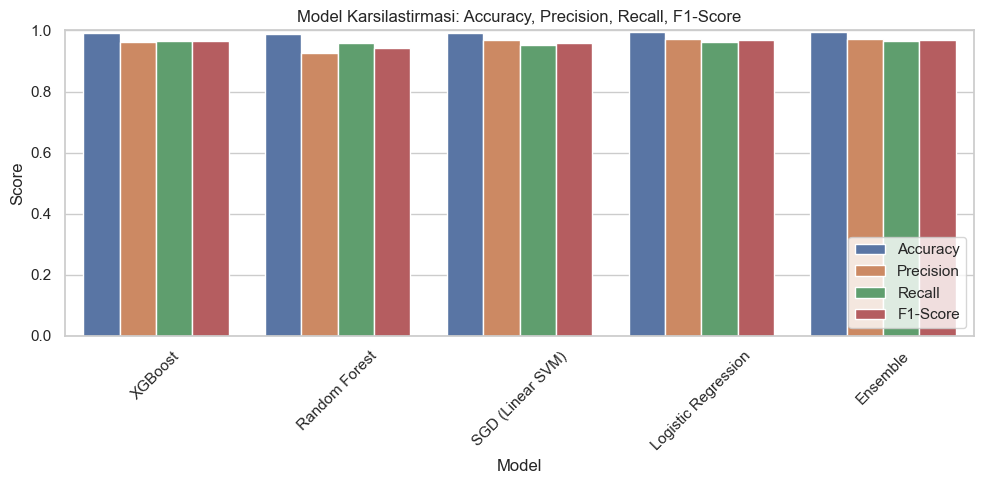

./plots/model_performance_comparison.png basariyla kaydedildi.

Tum modeller (Ensemble dahil):

              Model Accuracy Precision Recall F1-Score
            XGBoost   0.9924    0.9626 0.9652   0.9639
      Random Forest   0.9876    0.9257 0.9590   0.9421
   SGD (Linear SVM)   0.9916    0.9685 0.9511   0.9597
Logistic Regression   0.9932    0.9729 0.9619   0.9674
           Ensemble   0.9932    0.9707 0.9641   0.9674


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.992397,0.962576,0.965161,0.963867
1,Random Forest,0.987604,0.925730,0.958960,0.942052
2,SGD (Linear SVM),0.991610,0.968455,0.951129,0.959714
3,Logistic Regression,0.993183,0.972914,0.961903,0.967378
4,Ensemble,0.993171,0.970734,0.964075,0.967393


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot klasoru garanti
os.makedirs("plots", exist_ok=True)

# metrics_rows onceki adimlardan geliyor
metrics_df = pd.DataFrame(metrics_rows)

# Dataframe'i uzun formata cevir
metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

# Barplot
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Karsilastirmasi: Accuracy, Precision, Recall, F1-Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./plots/model_performance_comparison.png", dpi=150)
plt.show()
plt.close()

print("./plots/model_performance_comparison.png basariyla kaydedildi.")

# Guncel metrik tablosu (Ensemble dahil)
metrics_df = pd.DataFrame(metrics_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
print("\nTum modeller (Ensemble dahil):\n")
print(metrics_df.to_string(index=False, formatters={c: "{:.4f}".format for c in metric_cols}))
metrics_df.to_csv("./plots/model_metrics.csv", index=False, float_format="%.6f")
metrics_df